# Hertzsprung–Russell diagram generator

`plot_hr_diagram()` draws an HR diagram — luminosity in solar units against surface temperature, spectral type and true stellar colour — in which every component can be toggled on or off, so the diagram can be built up step by step for teaching. `save_hr_diagram_suite()` writes a set of high-resolution PNGs that together illustrate every feature without overcrowding any single plot.

**Star samples** (downloaded on first run, then cached in `hr_diagram_data/`):

- the ~1000 nearest stars, and an ~84 000-star all-sky sample within 200 pc, both from Gaia DR3 (Gaia Collaboration, Vallenari et al. 2023, A&A 674, A1);
- the ~100 brightest stars in the night sky, from the Hipparcos catalogue (Perryman et al. 1997, A&A 323, L49), which covers the very bright stars Gaia saturates on.

**Calibrations**: spectral types, masses and main-sequence luminosities from Pecaut & Mamajek 2013, ApJS 208, 9; star colours from the Planck spectrum via the CIE 1931 colour-matching functions (Wyman, Sloan & Shirley 2013, *J. Computer Graphics Techniques* 2(2)); B−V → temperature from Ballesteros 2012, EPL 97, 34008. Full citations sit as comments beside the code that uses them.

All quantities on the diagram are approximate and chosen for clarity of visualisation, not for quantitative analysis.

**Environment** — runs in the uv-managed env in this folder (`.venv/`, defined by `pyproject.toml`).

- Kernel picker (top right) → **HR diagram (uv)**, under *Jupyter Kernel*. VS Code remembers the choice afterwards.
- Add a package: `uv add <pkg>` in this folder, then restart the kernel.
- Env missing (new machine, deleted `.venv`)? In this folder run `uv sync`, then re-register the kernel:
  `uv run python -m ipykernel install --user --name hr-diagram --display-name "HR diagram (uv)"`

In [ ]:
# All plotting code lives in the installable package `hr_diagram`
# (src/hr_diagram/ in this folder, installed editable by `uv sync`).
# This notebook is a thin driver; edit the package to change the figures.
from hr_diagram import plot_hr_diagram, save_hr_diagram_suite

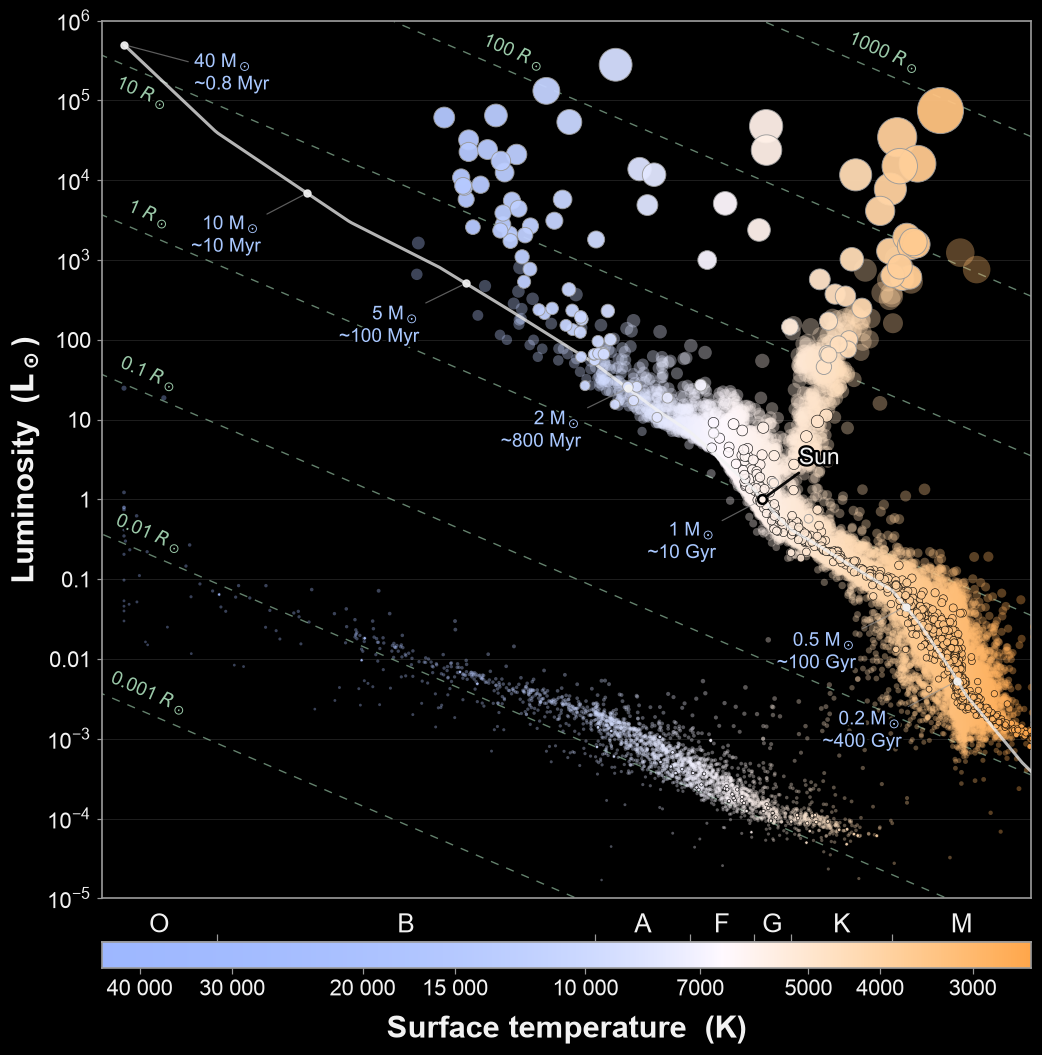

In [23]:
# The complete diagram, white-on-black, saved as a high-resolution PNG.
# Every feature below can be switched off individually; the shaded
# luminosity-class and star-group overlays are off by default and can be
# switched on with show_luminosity_classes=True / show_star_groups=True.
plot_hr_diagram(savepath="hr_diagram_full.png")

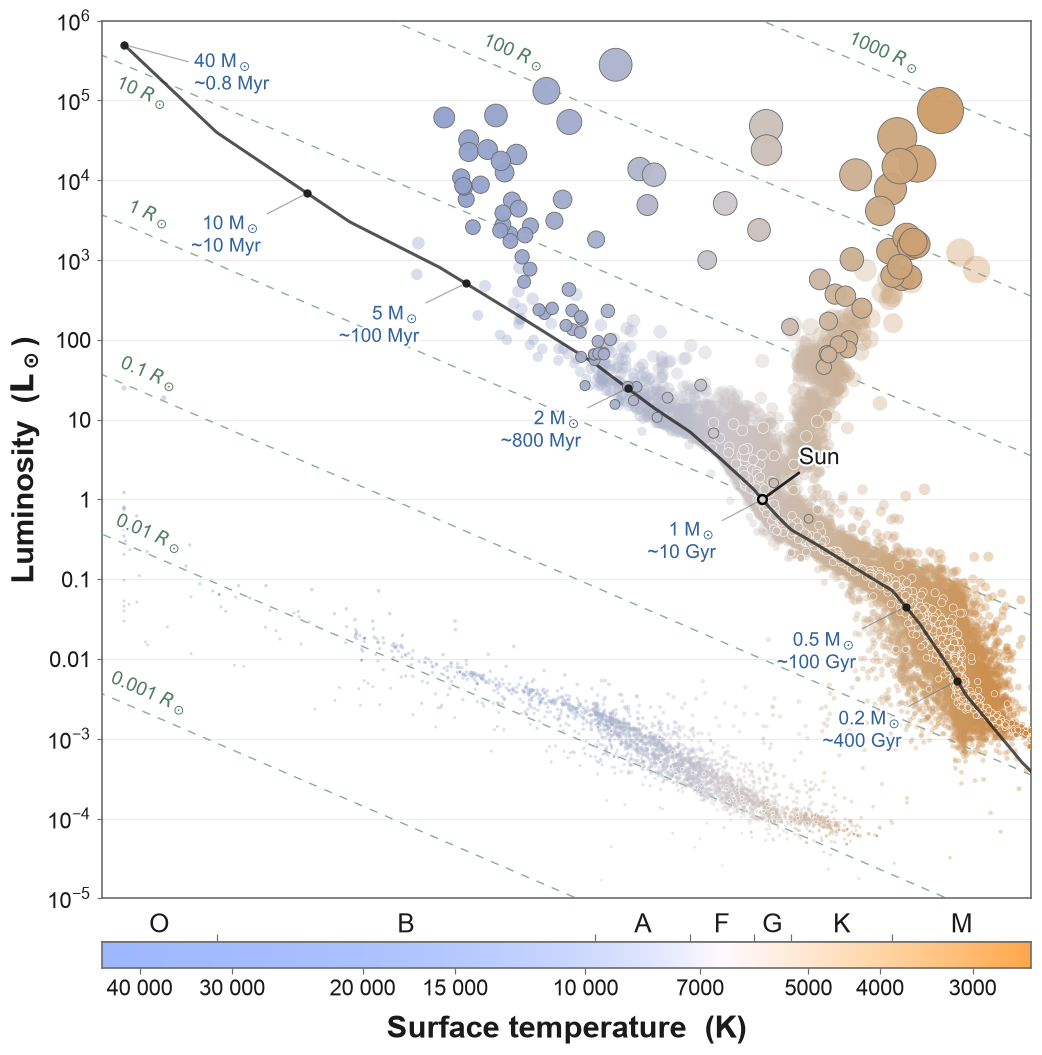

In [24]:
# The same diagram black-on-white
plot_hr_diagram(dark=False, savepath="hr_diagram_full_light.png")

In [25]:
# A set of diagrams that together illustrate every feature, one group at a
# time. Any option of plot_hr_diagram can be passed through, e.g.
# save_hr_diagram_suite(dark=False) for black-on-white versions.
save_hr_diagram_suite("hr_diagram_figures")

saved hr_diagram_figures/hr_diagram_01_axes_and_sun.png
saved hr_diagram_figures/hr_diagram_02_main_sequence.png
saved hr_diagram_figures/hr_diagram_03_radius_lines.png
saved hr_diagram_figures/hr_diagram_04_nearest_stars.png
saved hr_diagram_figures/hr_diagram_05_brightest_stars.png
saved hr_diagram_figures/hr_diagram_06_nearest_and_brightest.png
saved hr_diagram_figures/hr_diagram_07_gaia_sample.png
saved hr_diagram_figures/hr_diagram_08_full_diagram.png
saved hr_diagram_figures/hr_diagram_09_luminosity_classes.png
saved hr_diagram_figures/hr_diagram_10_star_groups.png
saved hr_diagram_figures/hr_diagram_11_famous_stars.png


['hr_diagram_figures/hr_diagram_01_axes_and_sun.png',
 'hr_diagram_figures/hr_diagram_02_main_sequence.png',
 'hr_diagram_figures/hr_diagram_03_radius_lines.png',
 'hr_diagram_figures/hr_diagram_04_nearest_stars.png',
 'hr_diagram_figures/hr_diagram_05_brightest_stars.png',
 'hr_diagram_figures/hr_diagram_06_nearest_and_brightest.png',
 'hr_diagram_figures/hr_diagram_07_gaia_sample.png',
 'hr_diagram_figures/hr_diagram_08_full_diagram.png',
 'hr_diagram_figures/hr_diagram_09_luminosity_classes.png',
 'hr_diagram_figures/hr_diagram_10_star_groups.png',
 'hr_diagram_figures/hr_diagram_11_famous_stars.png']

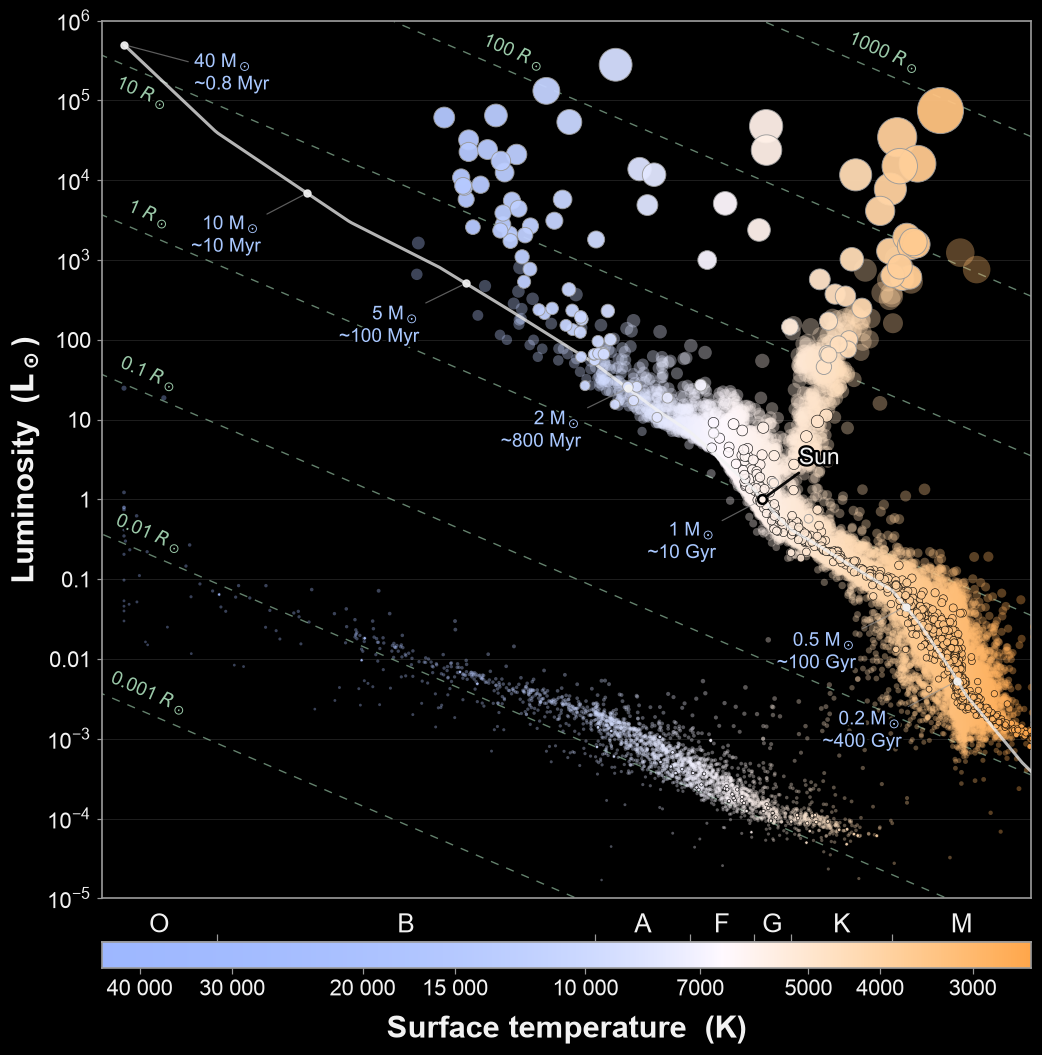

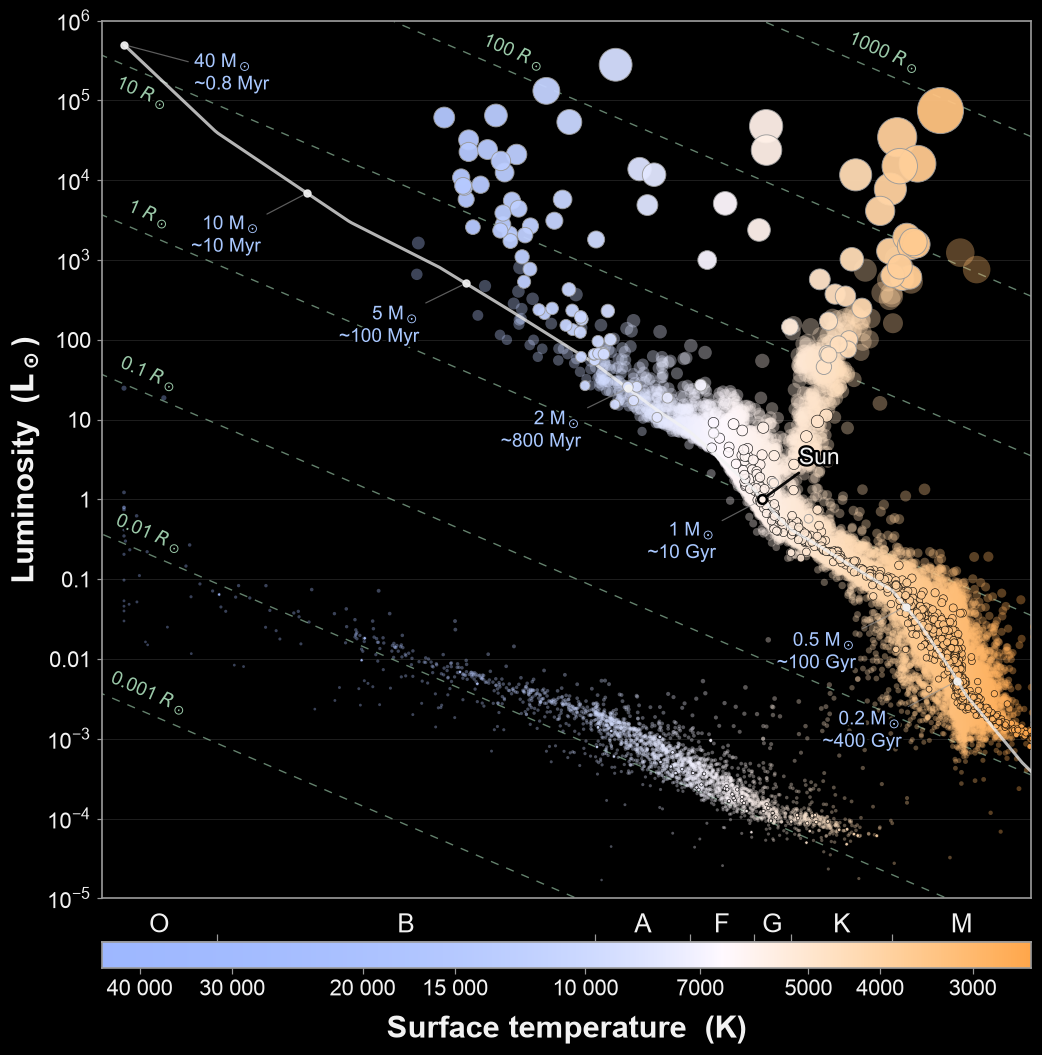

In [ ]:
# Render a version of the diagram by manually specifying every possible parameter in the function call:

plot_hr_diagram()

plot_hr_diagram(
        temp_lim=(2500.0, 45000.0),      # K; drawn with temperature increasing leftward
        lum_lim=(1e-5, 1e6),             # solar luminosities
        show_temp_labels=True,           # temperature tick labels (K)
        show_spectral_labels=True,       # O B A F G K M above the colour strip
        show_color_strip=True,           # true-colour bar under the temperature axis
        show_main_sequence=True,
        show_ms_annotations=True,        # masses and lifetimes along the main sequence
        show_radius_lines=True,          # lines of constant radius (0.01, 0.1, 1 ... Rsun)
        show_sun=True,
        show_nearest=True,               # ~1000 nearest stars (Gaia DR3)
        show_brightest=True,             # ~100 brightest stars (Hipparcos)
        show_gaia_sample=True,           # ~84 000-star Gaia DR3 sample within 200 pc
        show_famous_stars=True,         # labelled well-known stars
        show_luminosity_classes=True,   # MK luminosity-class regions, drawn over the stars
        show_star_groups=True,          # soft gradient clouds for notable star groups
        dark=True,                       # white-on-black (True) or black-on-white
        figsize=(10.0, 10.5),
        dpi=200,                         # resolution of the saved PNG
        savepath="hr_diagram_manual_features.png",                   # e.g. "hr_diagram.png"
        show=True)